# Neural Network Implementation


In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf #pip install tensorflow
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

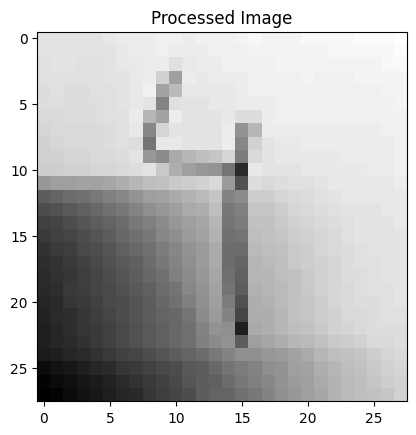

Shape of the processed image: (1, 28, 28)
Data type of the processed image: float32
Min value: 0.5254902
Max value: 0.78431374


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
# import requests # No longer needed for local files
from io import BytesIO

def preprocess_image(image_path):
    # Use Image.open() directly for local files
    img = Image.open(image_path)

    # Resize the image to 28x28
    img = img.resize((28, 28))

    # Convert to grayscale
    img = img.convert('L')

    img_array = np.array(img)

    # Normalize pixel values to the range [0, 1]
    img_array = img_array.astype('float32') / 255.0

    # Expand dimensions to make it a batch of 1 image
    img_array = np.expand_dims(img_array, axis=0)

    return img_array

if __name__ == '__main__':
  # Example usage
  image_path = "/content/01.jpeg"  # Local file path
  processed_image = preprocess_image(image_path)

  # Display the processed image
  plt.imshow(processed_image[0], cmap='gray')
  plt.title("Processed Image")
  plt.show()

  print("Shape of the processed image:", processed_image.shape)
  print("Data type of the processed image:", processed_image.dtype)
  print("Min value:", np.min(processed_image))
  print("Max value:", np.max(processed_image))

# Loading -"MNIST Data Set"
## Containing Training sample = 60,000 , Testing Samples = 10,000
### TensorFlow contains MNIST data set which can be loaded using Keras

In [ ]:
mnist = tf.keras.datasets.mnist  # Contains the MNIST dataset

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# # %cd digits
# # %ls


!unzip -q new_digits_2.zip -d /content/new_digits_2



In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from PIL import Image

# Directory containing your dataset
data_dir = "/content/new_digits_2/new_digits_2"

# Image dimensions (MNIST standard: 28x28)
img_height, img_width = 28, 28

# Initialize lists for images and labels
images = []
labels = []

# Loop through each folder and load images
for label in sorted(os.listdir(data_dir)):  # Sort ensures labels are in correct order
    label_path = os.path.join(data_dir, label)
    if os.path.isdir(label_path):
        for img_name in os.listdir(label_path):
            img_path = os.path.join(label_path, img_name)
            # Open the image, convert to grayscale, and resize
            img = Image.open(img_path).convert('L').resize((img_width, img_height))
            img_array = np.array(img) / 255.0  # Normalize to [0, 1]
            images.append(img_array)
            labels.append(int(label))  # Use folder name as label

# Convert to numpy arrays
images = np.array(images).reshape(-1, img_height, img_width, 1)  # Add channel dimension
labels = np.array(labels)

# Shuffle dataset
indices = np.arange(len(images))
np.random.shuffle(indices)
images = images[indices]
labels = labels[indices]

# Convert labels to one-hot encoding (if needed for training)
labels_one_hot = to_categorical(labels, num_classes=10)

# Optionally, split into training and test sets
split_idx = int(0.8 * len(images))
_, x_test = images[:split_idx], images[split_idx:]
_, y_test = labels_one_hot[:split_idx], labels_one_hot[split_idx:]

# Print shapes
print("Test data shape:", x_test.shape, y_test.shape)


(x_train, y_train), (_,_) = mnist.load_data()
print("Training data shape:", x_train.shape, y_train.shape)

Test data shape: (200, 28, 28, 1) (200, 10)
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28) (60000,)


# Train and Test datasets

In [ ]:
x_train.shape

(60000, 28, 28)

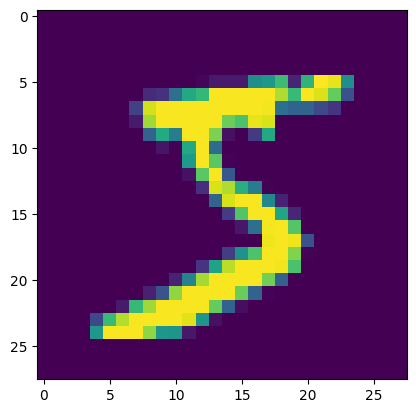

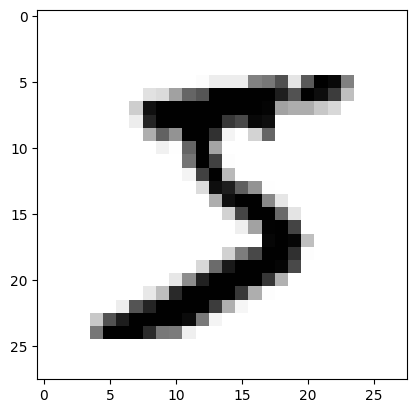

In [ ]:
import matplotlib.pyplot as plt #pip install matplotlib
plt.imshow(x_train[0])
plt.show() ## in order to execute the graph
#change the configuration
plt.imshow(x_train[0], cmap = plt.cm.binary)
plt.show()

# Checking the values of each pixel before Normalization

In [ ]:
print(x_train[0]) ## before normalize

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

## As images are in Gray level (1 channel ==> 0 to 255), not Colored (RGB)
# Normalizing the data | Pre-Processing Step

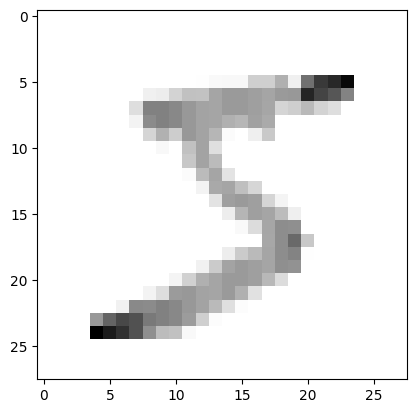

In [ ]:
x_train = tf.keras.utils.normalize (x_train, axis = 1)
x_test = tf.keras.utils.normalize (x_test, axis = 1)
plt.imshow(x_train[0], cmap = plt.cm.binary)


## After Normalization

In [ ]:
print(x_train[0])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [ ]:
print(y_train[0]) #Lable data set

5


## Resizing image to make it suitable for apply Convolution operation

In [ ]:
import numpy as np
IMG_SIZE = 28

x_trainr = x_train
x_testr = x_test
print("Training sample dimension", x_trainr.shape)
print("Testing sample dimension", x_testr.shape)

Training sample dimension (60000, 28, 28)
Testing sample dimension (200, 28, 28, 1)


# Creating a Deep Neural Network
### Training on 60,000 of MNIST handwritten dataset

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D

In [ ]:
import numpy as np
IMG_SIZE = 28

x_trainr = x_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1) # Reshape to add channel dimension
x_testr = x_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1)  # Reshape to add channel dimension
print("Training sample dimension", x_trainr.shape)
print("Testing sample dimension", x_testr.shape)

Training sample dimension (60000, 28, 28, 1)
Testing sample dimension (200, 28, 28, 1)


In [ ]:
### Creating a nn now
model = Sequential()

#### 1st Convolution layer
model.add(Conv2D(64, (3,3), input_shape = x_trainr.shape[1:])) ## only for 1st Convolution layer to mention input layer size
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size = (2,2)))


#### 2nd Convolution layer
model.add(Conv2D(64, (3,3), input_shape = x_trainr.shape[1:])) ## 2nd Convolution layer
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size = (2,2)))

#### 3rd Convolution layer
model.add(Conv2D(64, (3,3), input_shape = x_trainr.shape[1:])) ## 3rd Convolution layer
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size = (2,2)))

## FUlly connected layer # 1
model.add(Flatten())
model.add(Dense(64))
model.add(Activation("relu"))

## FUlly connected layer # 2
model.add(Dense(64))
model.add(Activation("relu"))

## Last FUlly connected layer # Output must equal to the no. of classes 10 (0-9)
model.add(Dense(10))  # Changed from 64 to 10
model.add(Activation("softmax")) # Activation function for multi-class classification

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 26, 26, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ (None, 26, 26, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 11, 11, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 11, 11, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 3, 3, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 3, 3, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 1, 1, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_9 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_10 (Activation)           │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_11 (Activation)           │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 83,466 (326.04 KB)

 Trainable params: 83,466 (326.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Total training samples = ",len(x_trainr))

Total training samples =  60000


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=['accuracy'])

In [ ]:
# Get training history
history = model.fit(x_trainr, y_train, epochs=5, validation_split=0.3)

# Plot accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Epoch 1/5


ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(None,), output.shape=(None, 10)

In [ ]:
test_loss , test_acc = model.evaluate(x_testr, y_test)
print("Test loss on 10,000 test samples: ",test_loss)
print("validation accuracy on 10,000 test samples: ",test_acc)

In [ ]:
print(predictions)


In [ ]:
print(np.argmax(predictions[99]))

In [ ]:
# Get predictions
predictions = model.predict(x_testr)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

# Calculate metrics
print(classification_report(true_classes, predicted_classes))
print("Confusion Matrix:")
print(confusion_matrix(true_classes, predicted_classes))
print("Accuracy:", accuracy_score(true_classes, predicted_classes))
print("Precision:", precision_score(true_classes, predicted_classes, average='weighted'))
print("Recall:", recall_score(true_classes, predicted_classes, average='weighted'))
print("F1-score:", f1_score(true_classes, predicted_classes, average='weighted'))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix




# Generate confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt="d")
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
plt.imshow(x_test[99])

In [ ]:
print(np.argmax(predictions[69]))

In [ ]:
plt.imshow(x_test[69])

In [ ]:
import cv2 #pip install opencv-python

In [ ]:
img = cv2.imread('/content/2024-12-08_16-21_3.png')

In [ ]:
plt.imshow(img)

In [ ]:
img.shape

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [ ]:
gray.shape

In [ ]:
resized = cv2.resize(gray, (28, 28), interpolation = cv2.INTER_AREA)

In [ ]:
resized.shape

In [ ]:
newimg = tf.keras.utils.normalize (resized, axis = 1)

In [ ]:
newimg = np.array(newimg).reshape(-1, IMG_SIZE, IMG_SIZE, 1)

In [ ]:
newimg.shape

In [ ]:
prediction = model.predict(newimg)
# print(prediction)

In [ ]:
print(np.argmax(prediction))

Test data shape: (200, 28, 28, 1) (200, 10)
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1) (60000, 10)
Testing data shape: (200, 28, 28, 1) (200, 10)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8089 - loss: 0.5927 - val_accuracy: 0.9710 - val_loss: 0.0964
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9730 - loss: 0.0913 - val_accuracy: 0.9800 - val_loss: 0.0673
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9809 - loss: 0.0618 - val_accuracy: 0.9808 - val_loss: 0.0639
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9844 - loss: 0.0495 - val_accuracy: 0.9784 - val_loss: 0.0737
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9880 - loss: 0.0400 - val_accuracy: 0.9816 - val_loss: 0.0663


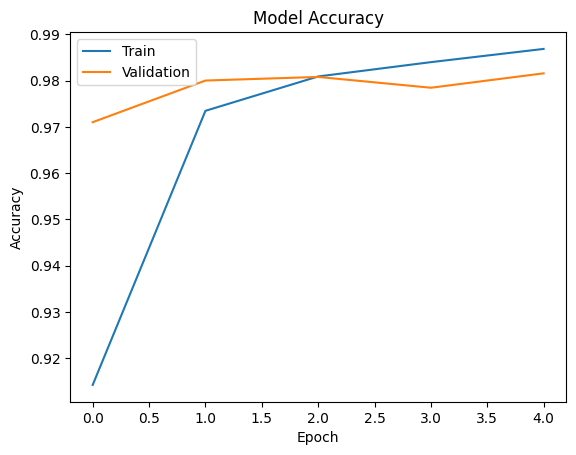

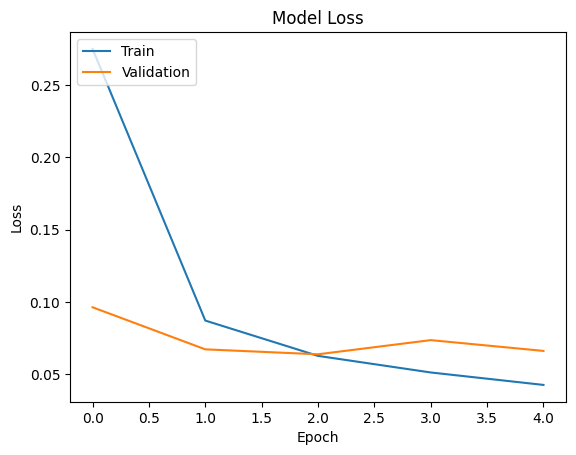

Test Accuracy: 0.54
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.61      0.74        23
           1       0.43      0.59      0.50        22
           2       0.36      0.79      0.49        19
           3       0.75      0.86      0.80        14
           4       1.00      0.21      0.35        19
           5       0.46      0.79      0.58        24
           6       0.73      0.80      0.76        20
           7       0.00      0.00      0.00        20
           8       1.00      0.30      0.46        20
           9       0.75      0.47      0.58        19

    accuracy                           0.54       200
   macro avg       0.64      0.54      0.53       200
weighted avg       0.64      0.54      0.52       200

Confusion Matrix:
[[14  2  0  0  0  2  0  5  0  0]
 [ 0 13  5  0  0  0  4  0  0  0]
 [ 1  0 15  0  0  3  0  0  0  0]
 [ 0  0  0 12  0  2  0  0  0  0]
 [ 0  0  1

In [ ]:
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import os
import numpy as np
from tensorflow.keras.utils import to_categorical
from PIL import Image

# Directory containing your dataset
data_dir = "/content/new_digits_2/new_digits_2"

# Image dimensions (MNIST standard: 28x28)
img_height, img_width = 28, 28

# Initialize lists for images and labels
images = []
labels = []

# Load images and labels
for label in sorted(os.listdir(data_dir)):
    label_path = os.path.join(data_dir, label)
    if os.path.isdir(label_path):
        for img_name in os.listdir(label_path):
            img_path = os.path.join(label_path, img_name)
            img = Image.open(img_path).convert('L').resize((img_width, img_height))
            img_array = np.array(img) / 255.0  # Normalize to [0, 1]
            images.append(img_array)
            labels.append(int(label))

# Convert to numpy arrays
images = np.array(images).reshape(-1, img_height, img_width, 1)
labels = np.array(labels)

# Shuffle dataset
indices = np.arange(len(images))
np.random.shuffle(indices)
images = images[indices]
labels = labels[indices]

# One-hot encode labels
labels_one_hot = to_categorical(labels, num_classes=10)

# Split into training and test sets
split_idx = int(0.8 * len(images))
x_test = images[split_idx:]
y_test = labels_one_hot[split_idx:]

# Print test dataset shape
print("Test data shape:", x_test.shape, y_test.shape)

# Load MNIST dataset for training
(x_train, y_train), (_, _) = tf.keras.datasets.mnist.load_data()
x_trainr = x_train.reshape(-1, img_height, img_width, 1) / 255.0
y_train = to_categorical(y_train, num_classes=10)

print("Training data shape:", x_trainr.shape, y_train.shape)
print("Testing data shape:", x_test.shape, y_test.shape)

# Define CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(img_height, img_width, 1)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=['accuracy'])

# Train model
history = model.fit(x_trainr, y_train, epochs=5, validation_split=0.3)

# Plot accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Evaluate model on custom test dataset
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.2f}")

# Predictions and classification report
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Classification Report:")
print(classification_report(y_true, y_pred_classes))
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))


Test Accuracy: 0.54
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.61      0.74        23
           1       0.43      0.59      0.50        22
           2       0.36      0.79      0.49        19
           3       0.75      0.86      0.80        14
           4       1.00      0.21      0.35        19
           5       0.46      0.79      0.58        24
           6       0.73      0.80      0.76        20
           7       0.00      0.00      0.00        20
           8       1.00      0.30      0.46        20
           9       0.75      0.47      0.58        19

    accuracy                           0.54       200
   macro avg       0.64      0.54      0.53       200
weighted avg       0.64      0.54      0.52       200



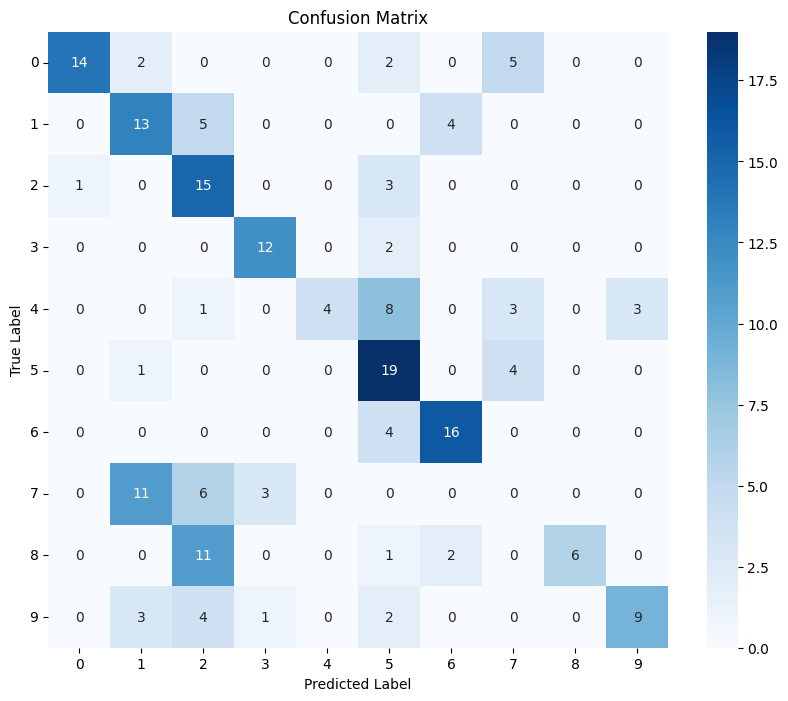

In [ ]:
import seaborn as sns

# Evaluate model on custom test dataset
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.2f}")

# Predictions and classification report
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Classification Report:")
print(classification_report(y_true, y_pred_classes))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(ticks=np.arange(10) + 0.5, labels=range(10))
plt.yticks(ticks=np.arange(10) + 0.5, labels=range(10), rotation=0)
plt.show()
